In [1]:
#undef __noinline__

# Simple Ray Tracer

This notebook renders a 3D scene purely on the GPU. It is a minimal ray tracer
that casts one ray per pixel straight through the image plane and finds the
closest sphere the ray intersects.

## The Scene

We place 20 spheres at random positions in a volume in front of the camera.
Each sphere has a random colour and radius.

![Ray Tracing](images/ray_tracing.png)

The camera sits at the origin looking in the +Z direction. Every pixel fires
a ray parallel to Z, described only by its (ox, oy) offset from the image centre.
Because all rays point the same direction, finding the intersection reduces to a
2D circle hit-test — much simpler than a full ray tracer.

In [2]:
#include <stdlib.h>
#include <stdio.h>
#include <math.h>

#define DIM     1024
#define SPHERES 20
#define INF     2e10f
#define rnd(x)  ((x) * (float)rand() / RAND_MAX)

## The Sphere struct

Each sphere stores colour, radius, and position. The `hit` method answers:
*does the ray at screen offset (ox, oy) intersect this sphere, and if so, how deep?*

It works by computing the 2D distance from the ray to the sphere centre.
If that distance is less than the radius, the ray enters the sphere and we
calculate the depth `dz` using the Pythagorean theorem.

In [3]:
struct Sphere {
    float r, g, b;    // colour
    float radius;
    float x, y, z;    // centre position

    __device__ float hit(float ox, float oy, float *normal_out) {
        float dx = ox - x;
        float dy = oy - y;
        float dist2 = dx * dx + dy * dy;

        if (dist2 < radius * radius) {
            float dz;
            float depth_sq = radius * radius - dist2;
            asm("sqrt.rn.f32 %0, %1;" : "=f"(dz) : "f"(depth_sq));

            *normal_out = dz / radius;   // surface normal component (for lighting)
            return dz + z;               // depth of intersection
        }
        return -INF;    // miss
    }
};

## The kernel

Each thread owns one pixel. It loops over every sphere, calls `hit`, and keeps track
of the sphere that was hit at the greatest depth (closest to the camera).
The sphere's colour, scaled by the surface normal, gives simple diffuse shading.

In [4]:
__global__ void raytrace(Sphere *spheres, unsigned char *image) {
    int px = threadIdx.x + blockIdx.x * blockDim.x;
    int py = threadIdx.y + blockIdx.y * blockDim.y;
    int offset = px + py * blockDim.x * gridDim.x;

    float ox = px - DIM / 2.0f;
    float oy = py - DIM / 2.0f;

    float r = 0, g = 0, b = 0;
    float closest = -INF;

    for (int s = 0; s < SPHERES; s++) {
        float normal;
        float depth = spheres[s].hit(ox, oy, &normal);
        if (depth > closest) {
            closest = depth;
            r = spheres[s].r * normal;
            g = spheres[s].g * normal;
            b = spheres[s].b * normal;
        }
    }

    image[offset * 4 + 0] = (unsigned char)(r * 255);
    image[offset * 4 + 1] = (unsigned char)(g * 255);
    image[offset * 4 + 2] = (unsigned char)(b * 255);
    image[offset * 4 + 3] = 255;
}

Here we configure all variables and create the random spheres on the CPU, then copy them to the GPU.

In [5]:
unsigned char *d_image, *h_image;
Sphere *d_spheres;

h_image = (unsigned char*)malloc(DIM * DIM * 4);
cudaMalloc((void**)&d_image,   DIM * DIM * 4);
cudaMalloc((void**)&d_spheres, sizeof(Sphere) * SPHERES);

// Build the scene on the CPU
Sphere scene[SPHERES];
srand(42);
for (int i = 0; i < SPHERES; i++) {
    scene[i].r      = rnd(1.0f);
    scene[i].g      = rnd(1.0f);
    scene[i].b      = rnd(1.0f);
    scene[i].x      = rnd(1000.0f) - 500.0f;
    scene[i].y      = rnd(1000.0f) - 500.0f;
    scene[i].z      = rnd(1000.0f) - 500.0f;
    scene[i].radius = rnd(80.0f) + 20.0f;
}
cudaMemcpy(d_spheres, scene, sizeof(Sphere) * SPHERES, cudaMemcpyHostToDevice);

Now we call the kernel and display the final picture.

In [6]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

dim3 blocks(DIM / 16, DIM / 16);
dim3 threads(16, 16);
raytrace<<<blocks, threads>>>(d_spheres, d_image);
cudaDeviceSynchronize();

cudaMemcpy(h_image, d_image, DIM * DIM * 4, cudaMemcpyDeviceToHost);

stbi_write_png("images/RayTrace.png", DIM, DIM, 4, h_image, DIM * 4);

cudaFree(d_image);
cudaFree(d_spheres);
free(h_image);

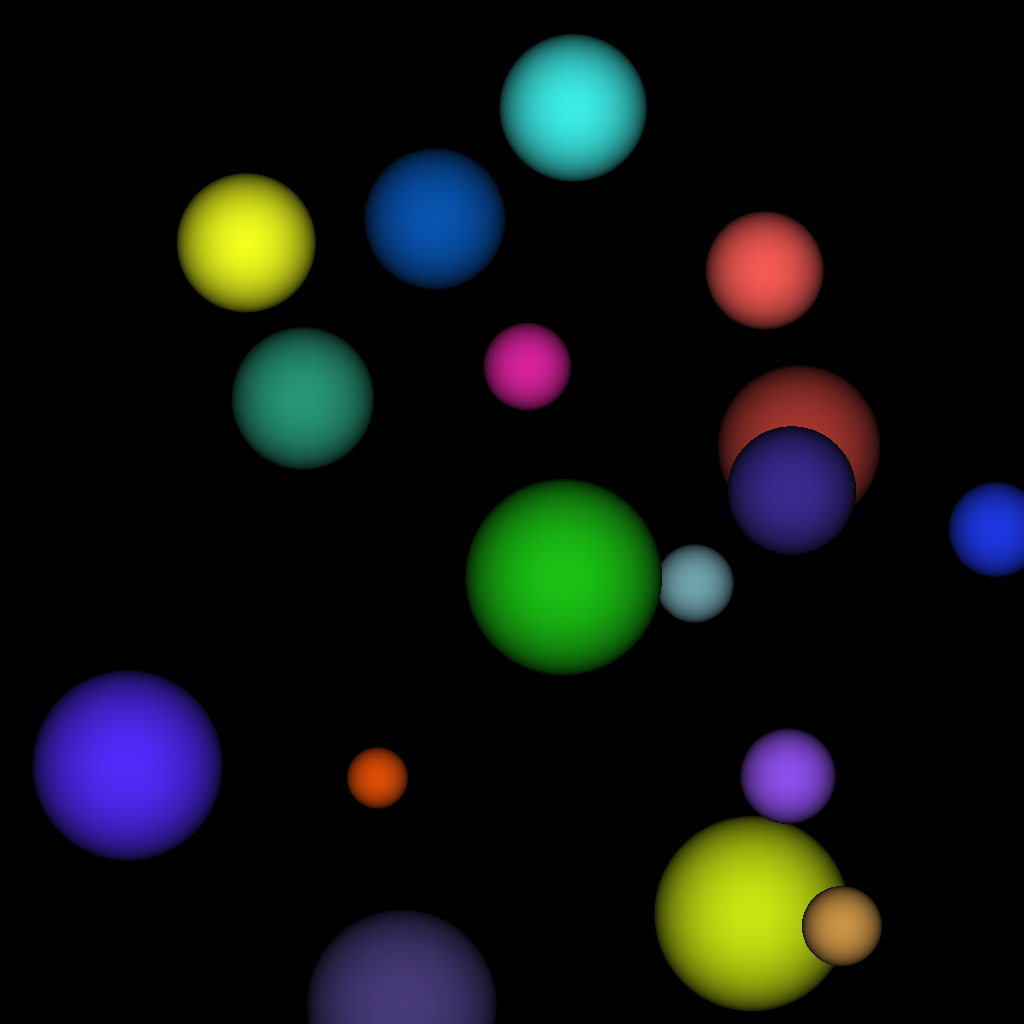

In [7]:
#include "headers/display.hpp"

im::image rt_image("images/RayTrace.png");
xcpp::display(rt_image);